# Tutorial 4 — Searchlight Analysis

**Learning objectives**
1. Understand the motivation for searchlight analysis vs. whole-brain or ROI MVPA
2. Explain how searchlight spheres sample local spatial patterns
3. Run a whole-brain searchlight using nilearn's `SearchLight`
4. Interpret and threshold a searchlight accuracy map
5. Identify peak decoding locations and relate them to anatomy

---


## Section 0 — Setup

In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
from nilearn import image, plotting
from nilearn.maskers import NiftiMasker
from nilearn.decoding import SearchLight
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import LeaveOneGroupOut, StratifiedKFold
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
from fmri_helpers import run_searchlight, summarise_searchlight, track_runtime

SUBJECT    = "sub-1"
USER          = os.getenv("USER")
DERIV_ROOT = f"/scratch/alpine/{USER}/haxby2001/derivatives"

MANIFEST_CSV = f"{DERIV_ROOT}/beta_weights/{SUBJECT}/beta_manifest_lss.csv"
MASK_FILE    = (f"{DERIV_ROOT}/beta_weights/{SUBJECT}/warped_masks/"
                f"{SUBJECT}_task-objectviewing_run-01_desc-warpedGroupMask_funcspace.nii.gz")
OUTPUT_DIR   = f"{DERIV_ROOT}/mvpa/searchlight_r6_lss/{SUBJECT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Manifest exists: {os.path.exists(MANIFEST_CSV)}")
print(f"Mask exists    : {os.path.exists(MASK_FILE)}")


Manifest exists: True
Mask exists    : True


---
## Section 1 — Why Searchlight?

### The localisation problem in MVPA

Whole-brain MVPA (Tutorial 3) tells you that the brain *as a whole* can decode
condition identity from the spatial pattern of activation.
But **where** in the brain does this information live?

Options:

| Approach | Pros | Cons |
|---|---|---|
| Whole-brain MVPA + importance map | Simple | SVM weights reflect a single global discriminant |
| ROI-based MVPA | Focused; interpretable | Requires prior hypothesis about which regions to test |
| **Searchlight** | Data-driven; spatially resolved | Computationally expensive; localisation biased toward large clusters |

### How searchlight works (Kriegeskorte et al. 2006)

For each voxel in the brain:
1. Define a sphere of radius *r* mm centred on that voxel (the "searchlight")
2. Extract the multi-voxel pattern inside the sphere for each trial
3. Decode condition identity using cross-validated SVM
4. Assign the resulting accuracy to the centre voxel

The output is a 3D accuracy map: high values indicate local regions whose
activity patterns carry information about stimulus identity.


In [3]:
# Visualise what a searchlight sphere looks like

from nilearn import image as nli_image

# Create a tiny brain mask for illustration
mask_img = image.load_img(MASK_FILE)
affine   = mask_img.affine
shape    = mask_img.shape

# Pick the centre voxel of the mask
centre_vox = np.array(np.where(mask_img.get_fdata() > 0)).mean(axis=1).astype(int)
print(f"Centre voxel (voxel space): {centre_vox}")
print(f"Centre voxel (mm space)   : {nib.affines.apply_affine(affine, centre_vox).round(1)}")

# Conceptual illustration: a 6mm radius sphere captures ~33 voxels at 2mm resolution
vox_size_mm = abs(affine[0, 0])
radius_mm   = 8.0
radius_vox  = radius_mm / vox_size_mm
n_sphere    = int((4/3) * np.pi * radius_vox**3)
print(f"\nVoxel size : {vox_size_mm:.2f} mm")
print(f"Radius     : {radius_mm} mm  ≈  {radius_vox:.1f} voxels")
print(f"~Voxels in sphere : ~{n_sphere}")


Centre voxel (voxel space): [20 24 28]
Centre voxel (mm space)   : [ -1.8 -28.1 -13.1]

Voxel size : 3.50 mm
Radius     : 8.0 mm  ≈  2.3 voxels
~Voxels in sphere : ~50


---
## Section 2 — Building the 4D Trial Image

SearchLight expects a 4-D NIfTI where the 4th dimension is trials (not time).
We stack individual 3-D beta images into this format using `concat_imgs`.


In [4]:
manifest  = pd.read_csv(MANIFEST_CSV)
le        = LabelEncoder()
y         = le.fit_transform(manifest['condition'].values)
runs_arr  = manifest['run'].values.astype(int)
conditions= list(le.classes_)
chance    = 1.0 / len(conditions)

print(f"Conditions : {conditions}")
print(f"Trials     : {len(y)}")
print(f"Chance     : {chance*100:.1f}%")

# Stack beta images into 4D NIfTI
print("\nStacking beta images into 4D NIfTI...")
t0       = time.perf_counter()
beta_imgs = [nib.load(p) for p in manifest['beta_file']]
imgs_4d  = image.concat_imgs(beta_imgs)
print(f"  Shape: {imgs_4d.shape}  ({time.perf_counter()-t0:.1f}s)")


Conditions : ['bottle', 'cat', 'chair', 'face', 'house', 'scissors', 'scrambledpix', 'shoe']
Trials     : 1152
Chance     : 12.5%

Stacking beta images into 4D NIfTI...
  Shape: (40, 64, 64, 1152)  (45.7s)


### ✏️ Exercise 1 — Inspect the 4D trial image

1. Print the shape of `imgs_4d` — what does each dimension represent?
2. Extract the first trial image (volume 0) and plot it
3. Compare it to the second trial image (volume 1)

**Hint:** `image.index_img(imgs_4d, 0)` extracts the first volume.


In [ ]:
# YOUR CODE HERE

# 1. Print shape with explanation
print(f"4D image shape: {imgs_4d.shape}")
print("  Dimensions: (x, y, z, n_trials)")

# 2. Extract and plot trial 0
trial0 = ...  # image.index_img(...)
trial1 = ...

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plotting.plot_stat_map(trial0, display_mode='z', cut_coords=5,
                       colorbar=True, cmap='RdBu_r',
                       title=f"Trial 0 — {conditions[y[0]]}",
                       axes=axes[0])
plotting.plot_stat_map(trial1, display_mode='z', cut_coords=5,
                       colorbar=True, cmap='RdBu_r',
                       title=f"Trial 1 — {conditions[y[1]]}",
                       axes=axes[1])
plt.tight_layout(); plt.show()


---
## Section 3 — Running the Searchlight

nilearn's `SearchLight` handles the sphere construction and parallel CV internally.
Key parameters:

| Parameter | What it controls |
|---|---|
| `mask_img` | Voxels eligible to be included in any sphere |
| `process_mask_img` | Sphere centre voxels (can be smaller ROI or same as mask) |
| `radius` | Sphere radius in mm |
| `estimator` | Classifier (e.g. SVC) |
| `cv` | Cross-validation splitter |
| `n_jobs` | Parallel workers (−1 = all CPUs) |

⚠️ **Runtime warning:** Full brain searchlight on ~5000 voxels takes several minutes
on a workstation; on the cluster, request 8–16 CPUs.


In [6]:
mask_img = image.load_img(MASK_FILE)

# Cross-validation strategy
cv      = LeaveOneGroupOut()
groups  = runs_arr
cv_name = "Leave-One-Run-Out"

# Classifier
estimator = SVC(C=1.0, kernel='linear', class_weight='balanced', random_state=42)

# SearchLight object
sl = SearchLight(
    mask_img         = mask_img,
    process_mask_img = mask_img,       # full brain search
    radius           = 6.0,            # mm
    estimator        = estimator,
    cv               = cv,
    scoring          = 'accuracy',
    n_jobs           = -1,
    verbose          = 1,
)

n_centres = int((mask_img.get_fdata() > 0).sum())
print(f"Searchlight centres : {n_centres} voxels")
print(f"CV strategy         : {cv_name}")
print(f"\nStarting searchlight fit (this will take several minutes)...")


Searchlight centres : 5446 voxels
CV strategy         : Leave-One-Run-Out

Starting searchlight fit (this will take several minutes)...


In [ ]:
# ⚠️ Run this cell — it will take several minutes
with track_runtime("searchlight"):
    sl.fit(imgs_4d, y, groups=groups)

scores_arr = sl.scores_
scores_img = image.new_img_like(mask_img, scores_arr, copy_header=True)

raw_path = os.path.join(OUTPUT_DIR, f"{SUBJECT}_searchlight_accuracy_funcspace.nii.gz")
scores_img.to_filename(raw_path)
print(f"\nSaved: {raw_path}")

above = scores_arr[mask_img.get_fdata() > 0]
print(f"Mean accuracy (all voxels) : {above.mean()*100:.2f}%")
print(f"Peak accuracy              : {above.max()*100:.2f}%")
print(f"Voxels above chance ({chance*100:.1f}%): {(above > chance).sum()}")


---
## Section 4 — Visualising the Accuracy Map


In [ ]:
func_ref_path = (f"/pl/active/courses/2026_summer/neuroclass2026/"
                  f"ds000105/derivatives/fmriprep/{SUBJECT}/func/"
                  f"{SUBJECT}_task-objectviewing_run-1_boldref.nii.gz")
func_bg = nib.load(func_ref_path) if os.path.exists(func_ref_path) else None

# Full accuracy map (threshold at chance)
fig, ax = plt.subplots(figsize=(14, 4))
plotting.plot_stat_map(
    scores_img, bg_img=func_bg,
    display_mode='z', cut_coords=7, colorbar=True,
    title=f'Searchlight accuracy — r=6mm (chance={chance*100:.1f}%)',
    cmap='hot', threshold=chance, vmin=chance, axes=ax,
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'searchlight_accuracy_map.png'), dpi=150)
plt.show()

# Above-chance map only
above_data = scores_arr.copy()
above_data[above_data <= chance] = 0.0
above_img  = image.new_img_like(scores_img, above_data)

fig, ax = plt.subplots(figsize=(14, 4))
plotting.plot_stat_map(
    above_img, bg_img=func_bg,
    display_mode='z', cut_coords=7, colorbar=True,
    title=f'Above-chance searchlight voxels (>{chance*100:.1f}%)',
    cmap='hot', threshold=chance+0.001, vmin=chance, axes=ax,
)
plt.tight_layout(); plt.show()


### ✏️ Exercise 2 — Histogram of searchlight accuracies

1. Extract the accuracy values for all centre voxels
2. Plot a histogram of accuracy values
3. Add vertical lines for: chance level, mean accuracy, and peak accuracy
4. What proportion of voxels are above chance?


In [ ]:
# YOUR CODE HERE
mask_scores = scores_arr[mask_img.get_fdata() > 0]

fig, ax = plt.subplots(figsize=(8, 4))
# ... your histogram

# Add vertical lines:
# ax.axvline(chance, ...)      # chance
# ax.axvline(mask_scores.mean(), ...)   # mean
# ax.axvline(mask_scores.max(), ...)    # peak

pct_above = ...
print(f"Proportion above chance: {pct_above*100:.1f}%")


---
## Section 5 — Extracting Peak Voxels

The top-accuracy voxels can be localized using `summarise_searchlight()`.
This returns their MNI coordinates and accuracy values.


In [ ]:
summary, peaks_df = summarise_searchlight(
    scores_img       = scores_img,
    process_mask_img = mask_img,
    chance           = chance,
    top_n            = 20,
)

print("=== Searchlight Summary ===")
for k, v in summary.items():
    print(f"  {k:<35} {v}")

print(f"\n=== Top 10 Peak Voxels ===")
print(peaks_df.head(10).to_string(index=False))

# Save outputs
peaks_df.to_csv(os.path.join(OUTPUT_DIR, 'searchlight_top_voxels.csv'), index=False)
pd.DataFrame([{'subject': SUBJECT, **summary}]).to_csv(
    os.path.join(OUTPUT_DIR, 'searchlight_summary.csv'), index=False)
print(f"\nSaved CSV files to {OUTPUT_DIR}/")


### ✏️ Exercise 3 — Effect of searchlight radius

Run two additional searchlights with different radii (4mm and 10mm) and compare:
1. Mean accuracy across voxels
2. Number of voxels above chance
3. Peak accuracy

**Hint:** Create a new `SearchLight` object with a different `radius` parameter.
Use a subset of voxels as `process_mask_img` to speed things up if needed.


In [ ]:
# YOUR CODE HERE — compare radii
# Note: this may take 10+ minutes for full brain; consider using a smaller ROI

results_by_radius = {}
for radius in [4.0, 6.0, 10.0]:
    print(f"\nRadius = {radius} mm...")

    sl_r = SearchLight(
        mask_img         = mask_img,
        process_mask_img = mask_img,
        radius           = ...,
        estimator        = SVC(C=1.0, kernel='linear', class_weight='balanced', random_state=42),
        cv               = LeaveOneGroupOut(),
        scoring          = 'accuracy',
        n_jobs           = -1,
        verbose          = 0,
    )
    # sl_r.fit(imgs_4d, y, groups=groups)
    # ... collect results

# Compare
# for r, res in results_by_radius.items():
#     print(f"  r={r}mm  mean={res['mean']:.3f}  max={res['max']:.3f}  n_above={res['n_above']}")


---
## Summary

| Concept | Key take-away |
|---|---|
| Searchlight | Local decoding at every voxel; spatially resolved MVPA |
| Sphere radius | Trade-off: larger sphere = smoother map, lower spatial resolution |
| 4D input | Beta images stacked as 4th dim (trials) rather than time |
| Above-chance map | Voxels where local patterns exceed chance decoding |
| Peak voxels | Highest accuracy → most informative local regions |

**Next step:** Warp the accuracy map to MNI space and compare across subjects
using `group_aggregate.py` in the `slurm/` folder.

---


---
## 📖 Answer Key

### Exercise 1 — Inspect the 4D trial image

4D image shape: (40, 64, 64, 1152)
  dim 0-2: x, y, z spatial voxels
  dim 3  : trial index (not time!)


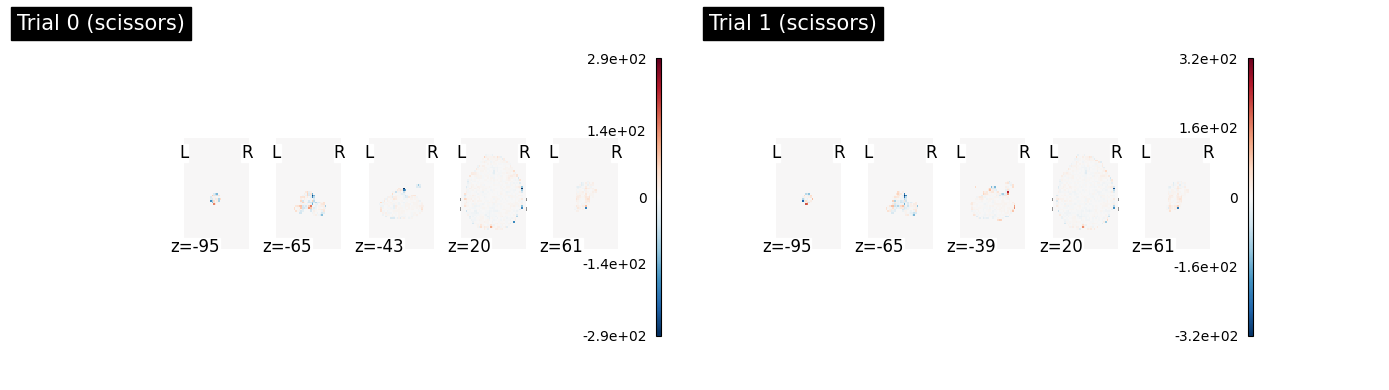

In [5]:
# ANSWER KEY — Exercise 1
print(f"4D image shape: {imgs_4d.shape}")
print("  dim 0-2: x, y, z spatial voxels")
print("  dim 3  : trial index (not time!)")

trial0 = image.index_img(imgs_4d, 0)
trial1 = image.index_img(imgs_4d, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plotting.plot_stat_map(trial0, display_mode='z', cut_coords=5, colorbar=True,
                       cmap='RdBu_r', title=f"Trial 0 ({conditions[y[0]]})", axes=axes[0])
plotting.plot_stat_map(trial1, display_mode='z', cut_coords=5, colorbar=True,
                       cmap='RdBu_r', title=f"Trial 1 ({conditions[y[1]]})", axes=axes[1])
plt.tight_layout(); plt.show()


### Exercise 2 — Histogram of searchlight accuracies

In [ ]:
# ANSWER KEY — Exercise 2
mask_scores = scores_arr[mask_img.get_fdata() > 0]
mean_acc    = mask_scores.mean()
peak_acc    = mask_scores.max()
pct_above   = (mask_scores > chance).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(mask_scores * 100, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
ax.axvline(chance*100,   color='gray',   lw=1.5, ls='--', label=f'Chance: {chance*100:.1f}%')
ax.axvline(mean_acc*100, color='orange', lw=1.5, ls='-',  label=f'Mean: {mean_acc*100:.2f}%')
ax.axvline(peak_acc*100, color='red',    lw=1.5, ls='-',  label=f'Peak: {peak_acc*100:.2f}%')
ax.set_xlabel('Decoding accuracy (%)'); ax.set_ylabel('Number of voxels')
ax.set_title('Searchlight accuracy distribution'); ax.legend()
plt.tight_layout(); plt.show()

print(f"Proportion above chance: {pct_above*100:.1f}%")


### Exercise 3 — Effect of searchlight radius

In [ ]:
# ANSWER KEY — Exercise 3
# (Showing the code structure; running all three radii takes ~30 min on a laptop)
# On the cluster: request 16 CPUs and it finishes in ~5 min

results_by_radius = {}
for radius in [4.0, 6.0, 10.0]:
    sl_r = SearchLight(
        mask_img=mask_img, process_mask_img=mask_img,
        radius=radius,
        estimator=SVC(C=1.0, kernel='linear', class_weight='balanced', random_state=42),
        cv=LeaveOneGroupOut(), scoring='accuracy', n_jobs=-1, verbose=0)
    sl_r.fit(imgs_4d, y, groups=groups)
    scores_r = sl_r.scores_
    mask_r   = scores_r[mask_img.get_fdata() > 0]
    results_by_radius[radius] = {
        'mean': float(mask_r.mean()), 'max': float(mask_r.max()),
        'n_above': int((mask_r > chance).sum())}
    print(f"  r={radius}mm  mean={mask_r.mean()*100:.2f}%  "
          f"max={mask_r.max()*100:.2f}%  n_above={results_by_radius[radius]['n_above']}")

# Key insight:
# Larger radii → smoother maps, often slightly higher mean accuracy
#             → but spatial precision is reduced (responses attributed to larger region)
# Smaller radii → more spatially precise but noisier (fewer voxels per sphere)
# 6mm is a common choice for 2mm resolution data
